In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense

Load Sample Weather Data

In [9]:
# Download a sample CSV (daily weather in Berlin)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
df = pd.read_csv(url)

# Preview
df.head()


,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


Preprocess the Data for Time Series Modeling

In [10]:
# Parameters
window_size = 7  # Number of past days to use
target_column = 'Temp'

# Normalize temperature values
scaler = MinMaxScaler()
df['Temp_scaled'] = scaler.fit_transform(df[['Temp']])

# Function to create input/output sequences
def create_sequences(data, window):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

# Create sequences
X, y = create_sequences(df['Temp_scaled'].values, window_size)

# Reshape X for LSTM/GRU [samples, timesteps, features]
X = X.reshape((X.shape[0], X.shape[1], 1))

# Split into training and test sets (80/20 split)
split_index = int(len(X) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]


Define and Train the LSTM Model

In [11]:
# Build the LSTM model
lstm_model = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], 1), return_sequences=False),
    Dense(1)
])

# Compile the model
lstm_model.compile(optimizer='adam', loss='mse')

# Train the model
history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    verbose=1
)


Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0669 - val_loss: 0.0107
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0120 - val_loss: 0.0101
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0120 - val_loss: 0.0098
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0119 - val_loss: 0.0096
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0120 - val_loss: 0.0094
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0112 - val_loss: 0.0094
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0109 - val_loss: 0.0091
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0107 - val_loss: 0.0091
Epoch 9/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0105 - val_loss: 0.0090
Epoch 10/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0105 - val_loss: 0.0087
Epoch 11/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0106 - val_loss: 0.0083
Epoch 12/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0107 - val_loss: 0.0083

Plot Training and Validation Loss

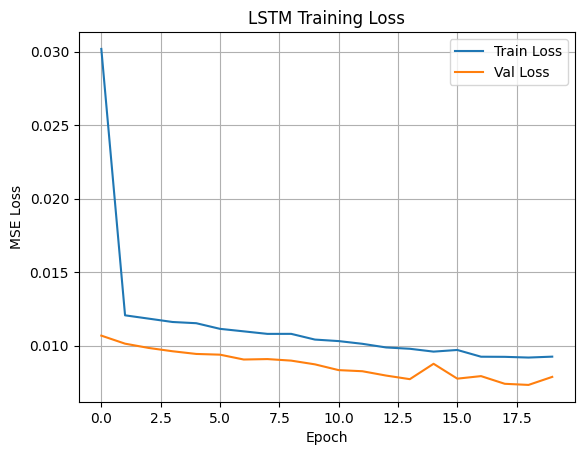

In [12]:
# Plot training & validation loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('LSTM Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()


Make Predictions & Inverse Transform

In [13]:
# Predict on test set
y_pred_scaled = lstm_model.predict(X_test)

# Invert scaling for predictions and true values
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_test.reshape(-1, 1))


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


Evaluate Model Performance

In [14]:
# Evaluation metrics

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)


print(f"LSTM MAE: {mae:.3f}")
print(f"LSTM RMSE: {rmse:.3f}")


LSTM MAE: 1.849
LSTM RMSE: 2.334


Plot Predicted vs Actual Values

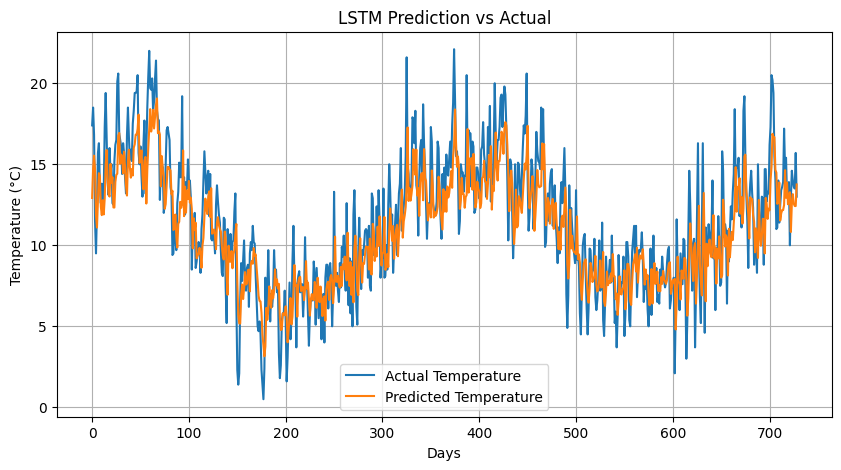

In [15]:
plt.figure(figsize=(10,5))
plt.plot(y_true, label='Actual Temperature')
plt.plot(y_pred, label='Predicted Temperature')
plt.title('LSTM Prediction vs Actual')
plt.xlabel('Days')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()


Baseline 1 — Persistence Model

In [16]:
# Persistence prediction: y[t] = y[t-1]
# We shift the test input by 1 day to use the last known temp as prediction
persistence_pred = X_test[:, -1, 0]  # last temp in each sequence
persistence_pred = persistence_pred.reshape(-1, 1)

# Inverse scale
persistence_pred = scaler.inverse_transform(persistence_pred)

# Evaluation
mae_persistence = mean_absolute_error(y_true, persistence_pred)
rmse_persistence = np.sqrt(mean_squared_error(y_true, persistence_pred))

print(f"Persistence MAE: {mae_persistence:.3f}")
print(f"Persistence RMSE: {rmse_persistence:.3f}")


Persistence MAE: 1.955
Persistence RMSE: 2.483


Baseline 2 — Climatology Model

In [17]:
# Add day-of-year to your original dataframe
df['Date'] = pd.to_datetime(df['Date'])
df['day_of_year'] = df['Date'].dt.dayofyear

# Map each day in the training set to its corresponding scaled target
df['Temp_scaled'] = scaler.transform(df[['Temp']])
df['Target'] = df['Temp_scaled'].shift(-1)  # create target column for prediction
train_dates = df.iloc[:len(y_train) + 7]  # +7 because of windowing offset

# Compute average temperature per day-of-year from training data
climatology_dict = train_dates.groupby('day_of_year')['Target'].mean().to_dict()

# Get the day_of_year for each test sample
test_start_idx = len(y_train) + 7
test_dates = df.iloc[test_start_idx: test_start_idx + len(y_test)]
test_days = test_dates['day_of_year'].values

# Predict using climatology for each day-of-year
climatology_pred_scaled = np.array([climatology_dict.get(day, np.mean(list(climatology_dict.values()))) for day in test_days]).reshape(-1, 1)

# Inverse scale the predictions
climatology_pred = scaler.inverse_transform(climatology_pred_scaled)

# Evaluate
mae_climatology = mean_absolute_error(y_true, climatology_pred)
rmse_climatology = np.sqrt(mean_squared_error(y_true, climatology_pred))

print(f"Climatology (Seasonal) MAE: {mae_climatology:.3f}")
print(f"Climatology (Seasonal) RMSE: {rmse_climatology:.3f}")


Climatology (Seasonal) MAE: 2.111
Climatology (Seasonal) RMSE: 2.705


Implement the GRU Model

In [18]:
# Build GRU model
gru_model = Sequential([
    GRU(64, input_shape=(X_train.shape[1], 1), return_sequences=False),
    Dense(1)
])

# Compile and train
gru_model.compile(optimizer='adam', loss='mse')
history_gru = gru_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    verbose=1
)

# Predict and inverse scale
y_pred_gru_scaled = gru_model.predict(X_test)
y_pred_gru = scaler.inverse_transform(y_pred_gru_scaled)

# Evaluate
mae_gru = mean_absolute_error(y_true, y_pred_gru)
rmse_gru = np.sqrt(mean_squared_error(y_true, y_pred_gru))

print(f"GRU MAE: {mae_gru:.3f}")
print(f"GRU RMSE: {rmse_gru:.3f}")


Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0433 - val_loss: 0.0097
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0107 - val_loss: 0.0088
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0106 - val_loss: 0.0083
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0103 - val_loss: 0.0081
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0097 - val_loss: 0.0083
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0097 - val_loss: 0.0077
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0091 - val_loss: 0.0075
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0094 - val_loss: 0.0074
Epoch 9/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0096 - val_loss: 0.0075
Epoch 10/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0092 - val_loss: 0.0073
Epoch 11/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0087 - val_loss: 0.0074
Epoch 12/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0095 - val_loss: 0.

Model Comparison Table

In [19]:
results = {
    "Model": ["LSTM", "GRU", "Persistence", "Climatology"],
    "MAE": [mae, mae_gru, mae_persistence, mae_climatology],
    "RMSE": [rmse, rmse_gru, rmse_persistence, rmse_climatology]
}

results_df = pd.DataFrame(results)
print(results_df)


         Model       MAE      RMSE
0         LSTM  1.849126  2.334287
1          GRU  1.784904  2.263436
2  Persistence  1.955144  2.482595
3  Climatology  2.110734  2.704584


Plot All Predictions Together

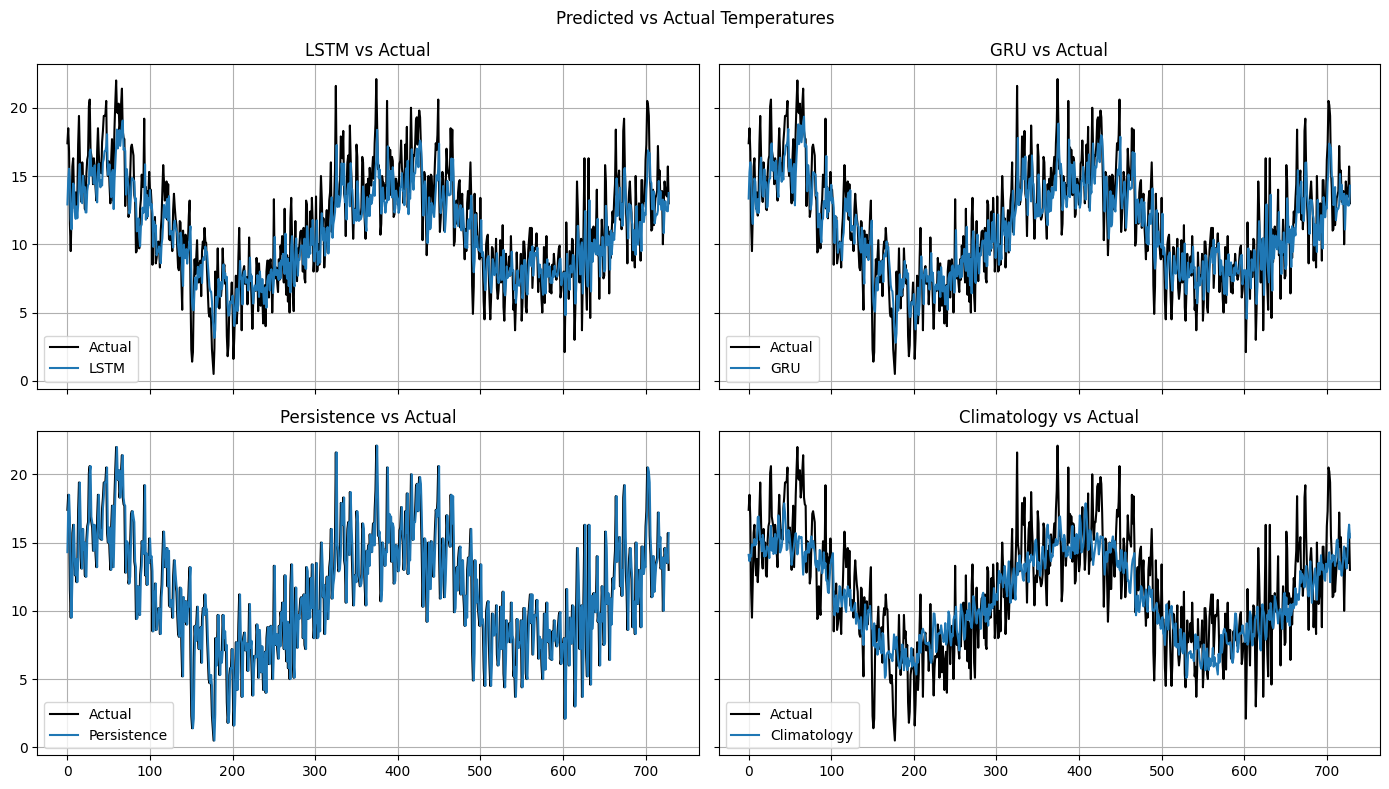

In [20]:
fig, axs = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)

axs[0, 0].plot(y_true, label='Actual', color='black')
axs[0, 0].plot(y_pred, label='LSTM')
axs[0, 0].set_title("LSTM vs Actual")

axs[0, 1].plot(y_true, label='Actual', color='black')
axs[0, 1].plot(y_pred_gru, label='GRU')
axs[0, 1].set_title("GRU vs Actual")

axs[1, 0].plot(y_true, label='Actual', color='black')
axs[1, 0].plot(persistence_pred, label='Persistence')
axs[1, 0].set_title("Persistence vs Actual")

axs[1, 1].plot(y_true, label='Actual', color='black')
axs[1, 1].plot(climatology_pred, label='Climatology')
axs[1, 1].set_title("Climatology vs Actual")

for ax in axs.flat:
    ax.legend()
    ax.grid(True)

fig.suptitle("Predicted vs Actual Temperatures")
plt.tight_layout()
plt.show()


Combined Loss Plot for Train & Test (LSTM vs GRU)

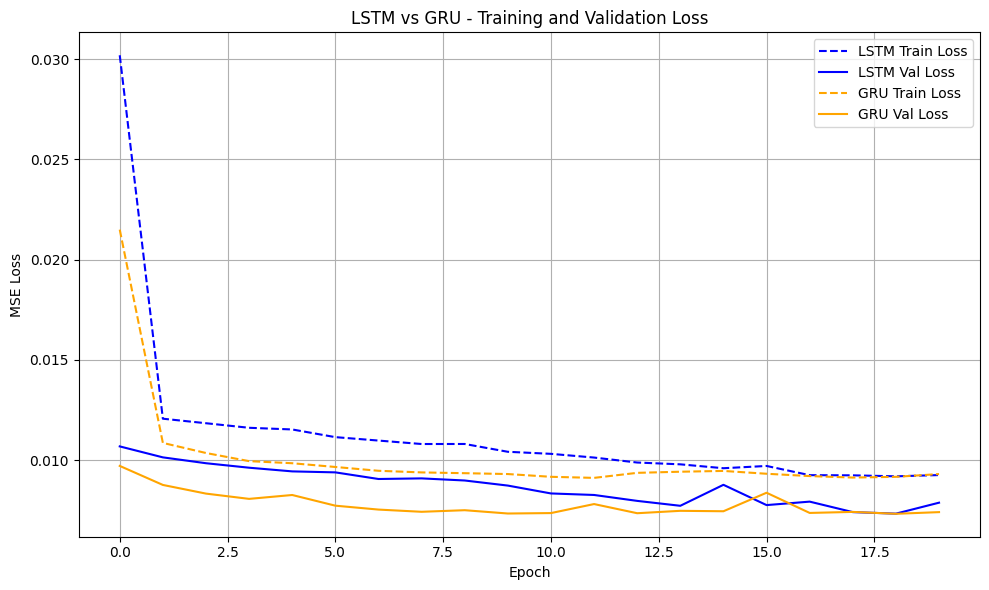

In [21]:
plt.figure(figsize=(10, 6))

# LSTM
plt.plot(history.history['loss'], label='LSTM Train Loss', linestyle='--', color='blue')
plt.plot(history.history['val_loss'], label='LSTM Val Loss', linestyle='-', color='blue')

# GRU
plt.plot(history_gru.history['loss'], label='GRU Train Loss', linestyle='--', color='orange')
plt.plot(history_gru.history['val_loss'], label='GRU Val Loss', linestyle='-', color='orange')

plt.title('LSTM vs GRU - Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("combined_loss_comparison.png")
plt.show()
